In [1]:
%cd ../../

/home/hoanghu/projects/ylva/fwo_models


In [2]:
from itertools import product

import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
# import lightning as L
# import torch.nn.functional as F
# from torch import nn
# from torch.optim import AdamW
# from torch.utils.data import Dataset, DataLoader
# import torch
# from torch.nn import Module
# from torch import Tensor
# from torchmetrics.regression import MeanSquaredError, R2Score
# from lightning.pytorch.callbacks import RichProgressBar
# from lightning.pytorch.loggers import TensorBoardLogger
# from sklearn.preprocessing import MinMaxScaler
from polars import DataFrame

from src import Data

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data and resources

In [4]:
data = Data()

## raw `pos`

In [5]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)
pos.head()

column_1,column_2,column_3,column_4,column_5,column_6,column_7
str,str,str,str,str,i64,str
"""2.1.2023""","""10:31""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:35""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:36""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",2,"""1,8"""


## Process dim tables

In [6]:
# Apply TruncateSVD to reduce embedding size
features = data.dim_embds["embedding_encoded"].to_numpy()
features_truncated = TruncatedSVD(n_components=5).fit_transform(features)
data.dim_embds = (
    data.dim_embds
    .with_columns(pl.Series('embedding', values=features_truncated))
)


data.dim_embds.head()

meal_id,embedding,meal_type,embedding_encoded
i64,"array[f32, 5]",str,"array[f32, 32]"
6949,"[0.441088, -0.533729, … 0.005513]","""meat""","[-0.01212, 0.130927, … -0.078509]"
90000003,"[-0.907147, 0.085389, … -0.084879]","""vegan""","[-0.115373, 0.024405, … 0.332012]"
6938,"[0.417018, -0.575372, … 0.023451]","""meat""","[-0.020777, 0.12986, … -0.087833]"
6855,"[0.721611, 0.685031, … 0.014544]","""fish""","[0.043915, -0.000287, … -0.112924]"
90000077,"[0.714352, 0.694665, … 0.022876]","""fish""","[0.031976, 0.007138, … -0.110438]"


## dim: `pos`

In [7]:
# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che',
    '610 Physicum': 'phy',
    '620 Exactum': 'exa',
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)


# Process meal
pos = (
    pos

    # Remove trailing spaces
    .with_columns(
        pl.col('meal').str.strip_chars(' ')
    )

    
    # Get meal_id
    .join(data.dim_meal_names, on='meal', how='left')

    
    # Remove entries having no `meal_id`
    .filter(pl.col('meal_id').is_not_null())
)

# Aggregate by date and supplement serving duration per day
pos = (
    pos
    .group_by('restaurant', pl.col('datetime').dt.date().alias('date'), 'meal_id')
    .agg(
        pl.col('pcs').sum(),
        pl.col('datetime').min().alias('time_start'),
        pl.col('datetime').max().alias('time_end'),
    )
    .with_columns(
        ((pl.col('time_end') - pl.col('time_start')).dt.total_minutes() / 60.).alias('serving_duration')
    )
    .join(
        data.dim_opentime.select('restaurant', 'working_duration'),
        on='restaurant',
        how='left'
    )
    .with_columns(
        (pl.col('serving_duration') / pl.col('working_duration')).alias('serving_percent')
    )
)



# Remove redundant columns
pos = pos.drop('time_start', 'time_end', 'serving_duration', 'working_duration')


# Add meal_type
pos = (
    pos
    .join(
        data.dim_meals.select('meal_id', 'meal_type'),
        on='meal_id',
        how='left'
    )

    # Ignore buffet
    .filter(pl.col('meal_type') != pl.lit('buffet'))
)


# Remove pos of leftover meals
pos = (
    pos
    .with_columns(
        pl.col('date').shift(1).over('restaurant', 'meal_id', order_by='date').alias('date_lag'),
        pl.col('pcs').shift(1).over('restaurant', 'meal_id', order_by='date').alias('pcs_lag'),
    )
    .filter(
        (pl.col('date_lag').is_null())
        | ((pl.col('date') - pl.col('date_lag')).dt.total_days() > 7)
    )
    .drop('date_lag', 'pcs_lag')
)  # fmt: skip

# Keep records whose POS value is greater than Q1 value
# pos = (
#     pos
#     .with_columns(
#         pl.col('pcs').quantile(.25).over('restaurant', 'meal_id', order_by='date').alias('pcs_q1')
#     )
#     .filter(pl.col('pcs') >= pl.col('pcs_q1'))
#     .drop('pcs_q1')
# )  # fmt: skip



# Keep THETA most consumed meals per date-restaurant
THETA = 4
pos = (
    pos
    .with_columns(
        pl.col('pcs') + np.random.rand(len(pos)) * 1e-3
    )
    .with_columns(
        pl.col('pcs').rank(method="dense", descending=True).over(['date', 'restaurant'], order_by='pcs').alias('rank')
    )
    .filter(pl.col('rank') <= THETA)
    .drop('rank')
)



pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type
str,date,i64,f64,f64,str
"""che""",2024-07-23,90000053,204.000808,0.744444,"""vegan"""
"""che""",2024-07-15,90000090,173.000799,0.777778,"""meat"""
"""vik""",2023-03-09,1151,16.000411,0.680952,"""vegetarian"""
"""che""",2023-02-28,941,150.000478,0.814815,"""vegan"""
"""exa""",2023-10-19,2579,36.000467,0.861111,"""vegetarian"""


In [8]:
serving_percent = pos.select('restaurant', 'date', 'meal_id', 'serving_percent')
serving_percent.head()

restaurant,date,meal_id,serving_percent
str,date,i64,f64
"""che""",2024-07-23,90000053,0.744444
"""che""",2024-07-15,90000090,0.777778
"""vik""",2023-03-09,1151,0.680952
"""che""",2023-02-28,941,0.814815
"""exa""",2023-10-19,2579,0.861111


# Craft feature

Idea: Refer every meals to `K` highest sale meals per restaurant - meal-type

## Permute the meals per day to augment data rows

In [9]:
CUTOFF_DATE = pl.lit("2024-09-01", dtype=pl.Date)

In [10]:
pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)
meals_old = pos_train.select(pl.col('meal_id').unique()).with_columns(pl.lit(False).alias('is_new'))

In [11]:
list_df = []

pos_aug = (
    pos
    .group_by('date', 'restaurant')
    .agg(pl.concat_list('meal_id').flatten())
)
for _ in range(100):
    df = (
        pos_aug
        .select(
            'date', 'restaurant',
            pl.col('meal_id').list.sample(fraction=1, shuffle=True)
        )
        .with_columns(
            # pl.col('meal_id').list.to_struct(
            #     n_field_strategy="max_width",
            #     fields=lambda idx: f"meal_{idx}"
            # ),
            pl.col('meal_id').cast(pl.List(pl.String)).list.join('-').alias('signature')
        )
    )
    list_df.append(df)
df = pl.concat(list_df)



df.head()

date,restaurant,meal_id,signature
date,str,list[i64],str
2023-03-07,"""che""","[1312, 880, 90000047]","""1312-880-90000047"""
2023-10-18,"""exa""","[90000074, 90000051, 1020]","""90000074-90000051-1020"""
2024-10-11,"""exa""","[90000136, 6128, 90000046]","""90000136-6128-90000046"""
2023-09-21,"""che""","[90000148, 90000105, … 90000106]","""90000148-90000105-7591-9000010…"
2024-03-26,"""phy""",[1026],"""1026"""


In [12]:
pos_final = (
    df
    .group_by('date', 'restaurant', 'signature')
    .first()
    # .unnest('meal_id')
    .drop('signature')
    .with_row_index()
    .explode('meal_id')
    .join(data.dim_embds.drop(['meal_type', 'embedding_encoded']), on='meal_id', how='left')
    .join(data.dim_meal_types, on='meal_id', how='left')
    .with_columns(
        pl.col('index').rank(method='ordinal').over('index').alias('meal_rank')
    )
    # .drop('meal_id')
)


# Encode meal type
enc_meal_type = OrdinalEncoder()
enc_meal_type.fit(pos_final.select('meal_type'))
pos_final = pos_final.with_columns(
    pl.Series('meal_type_enc', values=enc_meal_type.transform(pos_final.select('meal_type'))).arr.first().cast(pl.Int32) + 1,
)



# Pivot
pos_final = (
    pos_final
    .pivot(on='meal_rank', index=['index', 'date', 'restaurant'], values=['embedding', 'meal_id', 'meal_type_enc'])
    .rename({'meal_id_1': 'meal_id', 'meal_type_enc_1': 'meal_type_enc', 'embedding_1': 'embedding'})


    .join(pos, left_on=['date', 'restaurant', 'meal_id'], right_on=['date', 'restaurant', 'meal_id'])
    .drop('meal_id_2', 'meal_id_3', 'meal_id_4')
)


# Encode restaurant
enc_restaurant = OrdinalEncoder()
enc_restaurant.fit(pos_final.select('restaurant'))
pos_final = pos_final.with_columns(
    pl.Series('restaurant_enc', values=enc_restaurant.transform(pos_final.select('restaurant'))).arr.first().cast(pl.Int32) + 1,
)




# Encode datetime
pos_final = (
    pos_final
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.day().alias('day'),
        pl.col('date').dt.month().alias('month'),
    )
    .with_columns(
        (pl.col('weekday') * 2 * np.pi / 7).sin().alias('weekday_sin'),
        (pl.col('weekday') * 2 * np.pi / 7).cos().alias('weekday_cos'),
        (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
        (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
        (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
        (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    )
    .drop('weekday', 'day', 'month')
)



# Fill null
lit_embd_null = pl.lit([0., 0., 0., 0.,], dtype=pl.List)
lit_restaurant_null = lit_meal_type_null = 0

pos_final = (
    pos_final
    .select(
        'date', 'restaurant', 'meal_id',
        'restaurant_enc', 'meal_type_enc', 'serving_percent',
        'weekday_sin', 'weekday_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
        
        pl.col("^embedding.*$").fill_null(lit_embd_null),
        pl.col("^restaurant_enc_.*$").fill_null(lit_restaurant_null),
        pl.col("^meal_type_enc_.*$").fill_null(lit_meal_type_null),

        'pcs',
    )
)


# Flatten embedding vectors
pos_final = (
    pos_final
    .with_columns(
        pl.col("embedding").list.to_struct(n_field_strategy="max_width", fields=lambda idx: f"embd_{idx}"),
        pl.col("embedding_2").list.to_struct(n_field_strategy="max_width", fields=lambda idx: f"embd2_{idx}"),
        pl.col("embedding_3").list.to_struct(n_field_strategy="max_width", fields=lambda idx: f"embd3_{idx}"),
        pl.col("embedding_4").list.to_struct(n_field_strategy="max_width", fields=lambda idx: f"embd4_{idx}"),
    )
    .unnest('embedding', 'embedding_2', 'embedding_3', 'embedding_4')
)




# Add flag to track records are of old/new meals
pos_final = pos_final.join(meals_old, on='meal_id', how='left').with_columns(pl.col('is_new').fill_null(True))



pos_final.head()

/tmp/ipykernel_257985/3998812138.py:94: UserWarning: `to_struct()` should be passed a list of field names to avoid query errors in subsequent operations (e.g. <struct operation> not supported for dtype Unknown)
  pl.col("embedding").list.to_struct(n_field_strategy="max_width", fields=lambda idx: f"embd_{idx}"),
/tmp/ipykernel_257985/3998812138.py:95: UserWarning: `to_struct()` should be passed a list of field names to avoid query errors in subsequent operations (e.g. <struct operation> not supported for dtype Unknown)
  pl.col("embedding_2").list.to_struct(n_field_strategy="max_width", fields=lambda idx: f"embd2_{idx}"),
/tmp/ipykernel_257985/3998812138.py:96: UserWarning: `to_struct()` should be passed a list of field names to avoid query errors in subsequent operations (e.g. <struct operation> not supported for dtype Unknown)
  pl.col("embedding_3").list.to_struct(n_field_strategy="max_width", fields=lambda idx: f"embd3_{idx}"),
/tmp/ipykernel_257985/3998812138.py:97: UserWarning: `t

date,restaurant,meal_id,restaurant_enc,meal_type_enc,serving_percent,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,embd_0,embd_1,embd_2,embd_3,embd_4,embd2_0,embd2_1,embd2_2,embd2_3,embd2_4,embd3_0,embd3_1,embd3_2,embd3_3,embd3_4,embd4_0,embd4_1,embd4_2,embd4_3,embd4_4,meal_type_enc_2,meal_type_enc_3,meal_type_enc_4,pcs,is_new
date,str,i64,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,f64,bool
2023-01-24,"""vik""",90000124,4,2,0.990476,0.974928,-0.222521,-0.988468,0.151428,0.5,0.866025,0.724494,0.685308,-0.017619,-0.034426,0.008847,0.397779,-0.645189,-0.394789,-0.513355,0.012357,0.434006,-0.576118,0.686796,0.028813,0.004164,-0.89865,0.100356,0.002765,0.003806,0.039378,1,3,4,168.000386,false
2024-02-13,"""phy""",1450,3,5,0.743333,0.974928,-0.222521,0.485302,-0.874347,0.866025,0.5,0.391882,-0.532909,-0.333947,0.668087,0.012321,0.720992,0.685816,-0.029537,-0.037994,0.044376,0.723097,0.686759,-0.020644,-0.022495,0.026656,0.0,0.0,0.0,0.0,null,2,2,0,11.000592,false
2024-08-29,"""phy""",5379,3,3,0.45,-0.433884,-0.900969,-0.394356,0.918958,-0.866025,-0.5,0.432987,-0.593235,0.670723,0.055466,0.014438,0.408872,-0.538341,0.734289,-0.049755,-0.002861,0.391882,-0.532909,-0.333947,0.668087,0.012321,-0.901882,0.098536,0.000621,-0.019752,0.052804,3,5,4,8.000159,false
2024-05-27,"""che""",90000053,1,4,0.944444,0.781831,0.62349,-0.724793,0.688967,0.5,-0.866025,-0.896345,0.085439,-0.018992,-0.00309,0.05834,0.428399,-0.595276,0.676165,0.025787,0.037874,0.439987,-0.582253,0.680207,0.010121,0.023085,0.721425,0.687363,0.000666,-0.007961,0.002175,3,3,2,259.000291,false
2023-01-24,"""che""",6673,1,4,1.011111,0.974928,-0.222521,-0.988468,0.151428,0.5,0.866025,-0.898035,0.085348,0.002361,-0.038487,-0.104388,-0.899263,0.086011,0.005001,-0.02495,0.198314,0.714183,0.691409,-0.030146,-0.038257,-0.032398,0.0,0.0,0.0,0.0,null,4,2,0,168.000596,false


In [13]:
cols_X = [
    'restaurant_enc',
    'serving_percent',

    pl.col("^embd.*$"),
    pl.col("^meal_type_enc.*$"),

    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos'
]
col_y = 'pcs'
cols_cat = [
    'restaurant_enc',
    'meal_type_enc',
    'meal_type_enc_2',
    'meal_type_enc_3',
    'meal_type_enc_4',
]


pos_train = pos_final.filter(pl.col('date') < CUTOFF_DATE)
pos_val = pos_final.filter(pl.col('date') >= CUTOFF_DATE)

Xtrain, ytrain = pos_train.select(cols_X).to_pandas(), pos_train.get_column(col_y).to_pandas()
Xval, yval = pos_val.select(cols_X).to_pandas(), pos_val.get_column(col_y).to_pandas()

pos_train.head()

date,restaurant,meal_id,restaurant_enc,meal_type_enc,serving_percent,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,embd_0,embd_1,embd_2,embd_3,embd_4,embd2_0,embd2_1,embd2_2,embd2_3,embd2_4,embd3_0,embd3_1,embd3_2,embd3_3,embd3_4,embd4_0,embd4_1,embd4_2,embd4_3,embd4_4,meal_type_enc_2,meal_type_enc_3,meal_type_enc_4,pcs,is_new
date,str,i64,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,f64,bool
2023-01-24,"""vik""",90000124,4,2,0.990476,0.974928,-0.222521,-0.988468,0.151428,0.5,0.866025,0.724494,0.685308,-0.017619,-0.034426,0.008847,0.397779,-0.645189,-0.394789,-0.513355,0.012357,0.434006,-0.576118,0.686796,0.028813,0.004164,-0.89865,0.100356,0.002765,0.003806,0.039378,1,3,4,168.000386,false
2024-02-13,"""phy""",1450,3,5,0.743333,0.974928,-0.222521,0.485302,-0.874347,0.866025,0.5,0.391882,-0.532909,-0.333947,0.668087,0.012321,0.720992,0.685816,-0.029537,-0.037994,0.044376,0.723097,0.686759,-0.020644,-0.022495,0.026656,0.0,0.0,0.0,0.0,null,2,2,0,11.000592,false
2024-08-29,"""phy""",5379,3,3,0.45,-0.433884,-0.900969,-0.394356,0.918958,-0.866025,-0.5,0.432987,-0.593235,0.670723,0.055466,0.014438,0.408872,-0.538341,0.734289,-0.049755,-0.002861,0.391882,-0.532909,-0.333947,0.668087,0.012321,-0.901882,0.098536,0.000621,-0.019752,0.052804,3,5,4,8.000159,false
2024-05-27,"""che""",90000053,1,4,0.944444,0.781831,0.62349,-0.724793,0.688967,0.5,-0.866025,-0.896345,0.085439,-0.018992,-0.00309,0.05834,0.428399,-0.595276,0.676165,0.025787,0.037874,0.439987,-0.582253,0.680207,0.010121,0.023085,0.721425,0.687363,0.000666,-0.007961,0.002175,3,3,2,259.000291,false
2023-01-24,"""che""",6673,1,4,1.011111,0.974928,-0.222521,-0.988468,0.151428,0.5,0.866025,-0.898035,0.085348,0.002361,-0.038487,-0.104388,-0.899263,0.086011,0.005001,-0.02495,0.198314,0.714183,0.691409,-0.030146,-0.038257,-0.032398,0.0,0.0,0.0,0.0,null,4,2,0,168.000596,false


# Train

In [14]:
models = {
    'HistGB':   {'model': HistGradientBoostingRegressor(categorical_features=cols_cat), 'is_cat': True},
    'XGB-cat':  {'model': XGBRegressor(tree_method="hist", enable_categorical=True), 'is_cat': True},
    'CatBoost': {'model': CatBoostRegressor(verbose=False, cat_features=cols_cat), 'is_cat': True},
    'LBGM-cat': {'model': LGBMRegressor(verbose=0), 'is_cat': True},

    'RF':       {'model': RandomForestRegressor(n_jobs=-1), 'is_cat': False},
    'LBGM':     {'model': LGBMRegressor(verbose=0), 'is_cat': False},
    'XGB':      {'model': XGBRegressor(), 'is_cat': False},
}

for name, model in models.items():
    print(f"Start: {name}")

    X = Xtrain.copy()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    if name == 'LBGM-cat':
        kwargs = dict(categorical_feature=cols_cat)
    else:
        kwargs = {}
    model['model'].fit(X, ytrain, **kwargs)

Start: HistGB


Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


== Split: val
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB
== Split: train
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


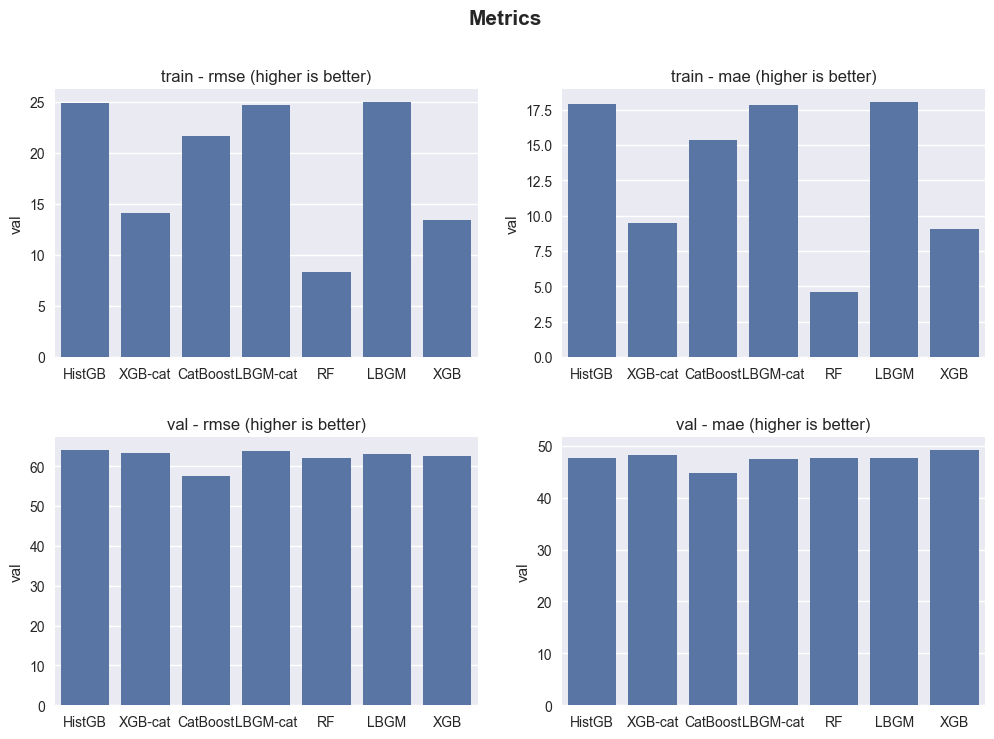

In [15]:
metrics_models = []

def calc_metrics(split: pl.DataFrame, model: dict, verbose: bool = False) -> tuple:
    X = split.select(cols_X).to_pandas()
    tgt = split.get_column(col_y).to_pandas()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    # split = (
    #     split
    #     .groupby(['date', 'restaurant', 'meal_id', 'meal_type'])
    #     .agg({'pcs': 'mean', 'pcs_pred': 'mean'})
    #     .reset_index()
    # )
    
    
    rmse = root_mean_squared_error(tgt, pcs_pred)
    mae = mean_absolute_error(tgt, pcs_pred)

    if verbose is True:
        print(f"rmse: {rmse:.4f}")
        print(f"mae : {mae:.4f}")

    return rmse, mae

print("== Split: val")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, mae = calc_metrics(pos_val, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'val', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': mae, 'split': 'val', 'metric': 'mae'})


print("== Split: train")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, mae = calc_metrics(pos_train, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'train', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': mae, 'split': 'train', 'metric': 'mae'})



# Visualize
metrics = pd.DataFrame.from_records(metrics_models)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Metrics", fontsize=15, fontweight='bold')
fig.subplots_adjust(wspace=0.2, hspace=0.3)

for i, (split, metric) in enumerate(product(['train', 'val'], ['rmse', 'mae'])):
    df = metrics[(metrics['split'] == split) & (metrics['metric'] == metric)]

    ax = fig.add_subplot(2, 2, i+1)
    sns.barplot(df, x='model', y='val', ax=ax)
    ax.set_title(f"{split} - {metric} (higher is better)")
    ax.set_xlabel("")


<Axes: xlabel='importance', ylabel='name'>

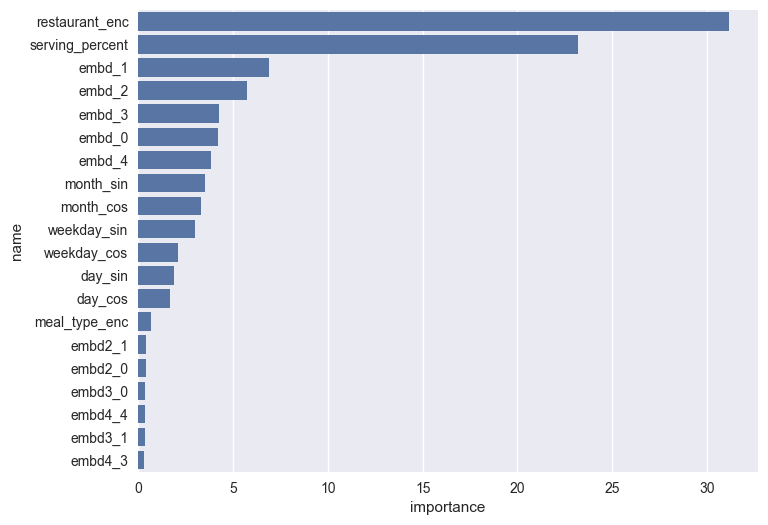

In [16]:
feat_imp = pd.DataFrame({
    'name': Xtrain.columns,
    'importance': models['CatBoost']['model'].feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(feat_imp[:20], y='name', x='importance', ax=ax)

## Separately analyze results of old and new meals

In [17]:
model = models['CatBoost']

In [18]:
split = pos_val.clone()

X = split.select(cols_X).to_pandas()
tgt = split.get_column(col_y).to_pandas()

if model['is_cat'] is True:
    for col in cols_cat:
        X[col] = X[col].astype('category')

pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))

split.head()

date,restaurant,meal_id,restaurant_enc,meal_type_enc,serving_percent,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,embd_0,embd_1,embd_2,embd_3,embd_4,embd2_0,embd2_1,embd2_2,embd2_3,embd2_4,embd3_0,embd3_1,embd3_2,embd3_3,embd3_4,embd4_0,embd4_1,embd4_2,embd4_3,embd4_4,meal_type_enc_2,meal_type_enc_3,meal_type_enc_4,pcs,is_new,pcs_pred
date,str,i64,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,f64,bool,f64
2024-09-13,"""exa""",90000093,2,4,0.9,-0.974928,-0.222521,0.485302,-0.874347,-1.0,-1.8370e-16,-0.898801,0.056876,0.017091,0.001771,0.027765,0.448691,-0.618127,-0.340918,-0.531268,0.023519,-0.900422,0.081037,0.024289,-0.005659,0.040496,0.0,0.0,0.0,0.0,null,1,4,0,226.000715,false,94.920604
2024-09-25,"""che""",90000016,1,4,0.962963,0.433884,-0.900969,-0.937752,0.347305,-1.0,-1.8370e-16,-0.886271,0.087922,-0.022434,-0.049336,-0.142632,0.34536,-0.670509,-0.392445,-0.503297,0.009244,-0.900525,0.078651,0.00856,-0.012128,0.057684,0.0,0.0,0.0,0.0,null,1,4,0,163.000513,false,240.355309
2024-09-06,"""che""",7007,1,4,0.992593,-0.974928,-0.222521,0.937752,0.347305,-1.0,-1.8370e-16,-0.895604,0.085873,-0.038587,-0.01366,0.011594,0.711858,0.695943,-0.018821,-0.021519,0.009333,0.390004,-0.664352,-0.349571,-0.527252,-0.019932,-0.89865,0.100356,0.002765,0.003806,0.039378,2,1,4,211.000492,false,268.699245
2024-10-15,"""vik""",6121,4,3,0.680952,0.974928,-0.222521,0.101168,-0.994869,-0.866025,0.5,0.423443,-0.545978,0.717591,-0.007576,0.038475,-0.902553,0.099548,-0.006051,-0.002822,-0.027533,-0.897584,0.072707,0.003957,-0.065721,0.19053,0.43626,-0.586051,0.677149,0.033328,0.009662,4,4,3,30.000417,false,66.475348
2024-10-21,"""vik""",6940,4,4,0.947619,0.781831,0.62349,-0.897805,-0.440394,-0.866025,0.5,-0.908407,0.119444,-0.007704,0.029296,0.015125,0.725505,0.682114,-0.022634,-0.035338,0.033713,-0.893019,0.105272,0.00354,-0.02723,-0.062463,-0.911142,0.078636,0.029106,-0.017395,-0.038233,2,4,4,36.000344,false,118.134035


In [19]:
split = pos_val.clone()

X = split.select(cols_X).to_pandas()
tgt = split.get_column(col_y).to_pandas()

if model['is_cat'] is True:
    for col in cols_cat:
        X[col] = X[col].astype('category')

pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))
    
split = (
    split
    .group_by(['date', 'restaurant', 'meal_id', 'serving_percent', 'is_new'])
    .agg(
        pl.col('pcs').mean(),
        pl.col('pcs_pred').mean(),
    )
)

split.head()

date,restaurant,meal_id,serving_percent,is_new,pcs,pcs_pred
date,str,i64,f64,bool,f64,f64
2024-09-25,"""exa""",90000135,0.95,false,111.000663,133.396369
2024-10-28,"""phy""",90000022,0.0,false,1.000695,6.962427
2024-09-11,"""exa""",9111,0.983333,true,105.00056,105.550498
2024-10-24,"""vik""",7599,0.804762,false,38.000594,82.1998
2024-10-31,"""che""",1307,0.981481,false,138.000418,234.00021


In [20]:
split_new = split.filter(pl.col('is_new'))
mae = mean_absolute_error(split_new.get_column('pcs'), split_new.get_column('pcs_pred'))
rmse = root_mean_squared_error(split_new.get_column('pcs'), split_new.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"mae : {mae:.4f}")

rmse: 60.5011
mae : 47.9572


In [21]:
split_old = split.filter(~pl.col('is_new'))
mae = mean_absolute_error(split_old.get_column('pcs'), split_old.get_column('pcs_pred'))
rmse = root_mean_squared_error(split_old.get_column('pcs'), split_old.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"mae : {mae:.4f}")

rmse: 53.7975
mae : 41.0867
